 # Import necessary libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load dataset

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Dispalys top 10 data

In [5]:
print("\nSample of data:")
df.head(10)


Sample of data:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
# Show basic info
print(f"Dataset loaded with shape: {df.shape}")
print(df.info())
# Basic descriptions
print(df.describe(include='object'))

Dataset loaded with shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pape

In [7]:
# Check missing values
missing_values = df.isnull().sum()
missing_percentage = missing_values / len(df) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values('Percentage', ascending=False)

print("\nMissing Values Analysis:")
print(missing_df[missing_df['Missing Values'] > 0])


Missing Values Analysis:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [8]:
print("\n--- Numerical summary ---")
display(df.describe().T)


--- Numerical summary ---


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [9]:
df['TotalCharges'].value_counts()

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [10]:
cat_cols = df.select_dtypes(include = ["object"]).columns.tolist()
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}\n")
cat_unique = pd.DataFrame({
    "col": cat_cols,
    "n_unique": [df[c].nunique() for c in cat_cols],
    "top_values_sample": [df[c].value_counts().index[:5].tolist() for c in cat_cols]
}).sort_values("n_unique", ascending = False)
print("--- Categorical unique counts & top values ---")
display(cat_unique.reset_index(drop = True))


Categorical columns (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

--- Categorical unique counts & top values ---


,col,n_unique,top_values_sample
0,customerID,7043,"[7590-VHVEG, 3791-LGQCY, 6008-NAIXK, 5956-YHHR..."
1,TotalCharges,6531,"[ , 20.2, 19.75, 20.05, 19.9]"
2,PaymentMethod,4,"[Electronic check, Mailed check, Bank transfer..."
3,OnlineBackup,3,"[No, Yes, No internet service]"
4,Contract,3,"[Month-to-month, Two year, One year]"
5,StreamingMovies,3,"[No, Yes, No internet service]"
6,StreamingTV,3,"[No, Yes, No internet service]"
7,TechSupport,3,"[No, Yes, No internet service]"
8,DeviceProtection,3,"[No, Yes, No internet service]"
9,OnlineSecurity,3,"[No, Yes, No internet service]"


In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

missing_total = df["TotalCharges"].isnull().sum()
print(f"Missing values in TotalCharges after conversion: {missing_total}")

df = df.dropna(subset = ["TotalCharges"])

cat_cols = df.select_dtypes(include = ["object"]).columns
for col in cat_cols:
    df[col] = df[col].str.strip()

print("Data cleaning completed.")
print("Shape after cleaning:", df.shape)

Missing values in TotalCharges after conversion: 11
Data cleaning completed.
Shape after cleaning: (7032, 21)


In [12]:
print("Original Churn unique values:", df["Churn"].unique())

df["Churn"] = df["Churn"].astype(str).str.strip().str.upper()  

df["Churn"] = df["Churn"].map({"YES": 1, "NO": 0})

print("Churn value counts after mapping:")
print(df["Churn"].value_counts(dropna = False))

numerical_cols = df.select_dtypes(include = [np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include = ["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "sample_values": df.apply(lambda x: x.unique()[:5])
})
display(summary)

Original Churn unique values: ['No' 'Yes']
Churn value counts after mapping:
Churn
0    5163
1    1869
Name: count, dtype: int64
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,dtype,n_unique,sample_values
customerID,object,7032,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
gender,object,2,"[Female, Male]"
SeniorCitizen,int64,2,"[0, 1]"
Partner,object,2,"[Yes, No]"
Dependents,object,2,"[No, Yes]"
tenure,int64,72,"[1, 34, 2, 45, 8]"
PhoneService,object,2,"[No, Yes]"
MultipleLines,object,3,"[No phone service, No, Yes]"
InternetService,object,3,"[DSL, Fiber optic, No]"
OnlineSecurity,object,3,"[No, Yes, No internet service]"


In [13]:
# Save to CSV
df.to_csv("Clean_Telco-Customer-Churn_data.csv", index=False)
print("Clean_Telco-Customer-Churn_data.csv")

Clean_Telco-Customer-Churn_data.csv


In [14]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)


Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [15]:
# Replace blank strings with NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# Convert 'TotalCharges' to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Drop rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Verify cleanup
print("After cleaning, number of missing values in 'TotalCharges':", df['TotalCharges'].isnull().sum())
print("Updated dataset shape:", df.shape)

After cleaning, number of missing values in 'TotalCharges': 0
Updated dataset shape: (7032, 21)


In [16]:
churn_counts = df['Churn'].value_counts(dropna = False)
churn_pct = df['Churn'].value_counts(normalize = True, dropna = False) * 100
churn_df = pd.concat([churn_counts.rename("count"), churn_pct.rename("percent")], axis = 1)
print("\n--- Target distribution: Churn ---")
display(churn_df)


--- Target distribution: Churn ---


,count,percent
Churn,,
0,5163,73.421502
1,1869,26.578498


# Data visualization

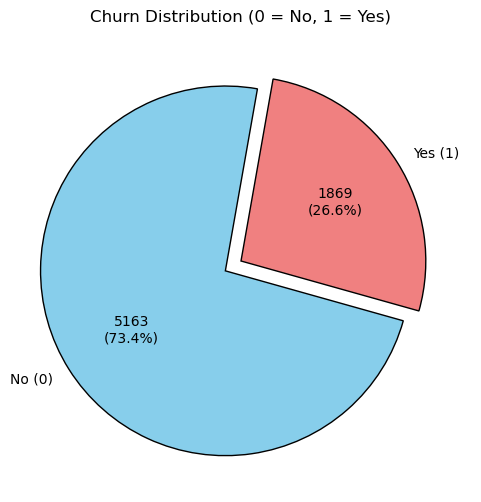

In [18]:
churn_counts = df['Churn'].value_counts().sort_index()  # 0 first, then 1
labels = ['No (0)', 'Yes (1)']
sizes = churn_counts.values

explode = [0.1 if size == max(sizes) else 0 for size in sizes]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct=lambda pct: f"{int(round(pct/100.*sum(sizes)))}\n({pct:.1f}%)",
        startangle=80, colors=['skyblue','lightcoral'], explode=explode, wedgeprops={'edgecolor':'Black'})
plt.title('Churn Distribution (0 = No, 1 = Yes)')
plt.show()

In [19]:
# List of categorical columns (excluding target)
categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

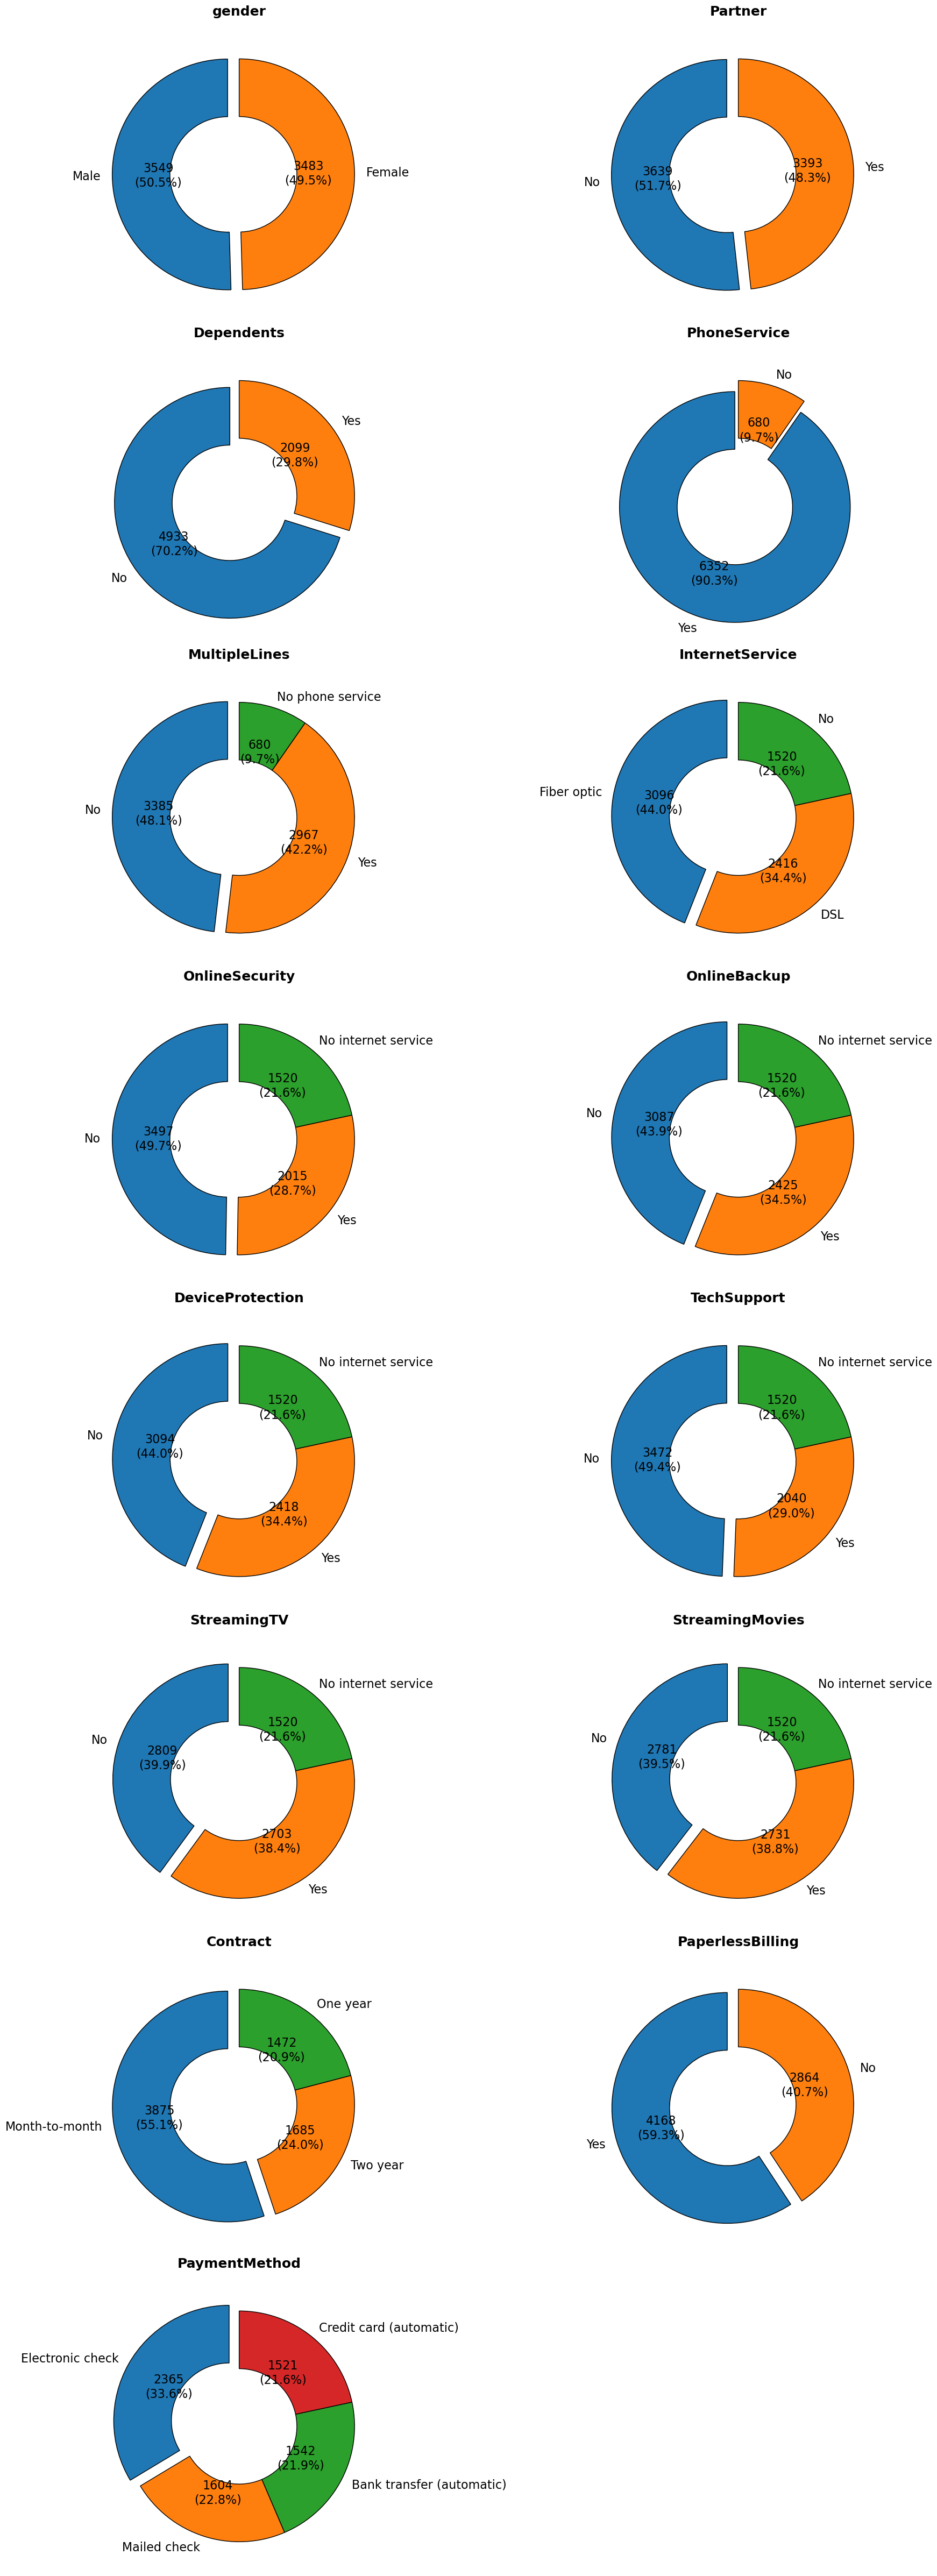

In [21]:
# Function to create clean donut plot with count + percentage
def donut_plot(column, data):
    counts = data[column].value_counts()
    labels = counts.index
    sizes = counts.values
    # Explode the largest value
    explode = [0.1 if i == 0 else 0 for i in range(len(sizes))]
    
    # Custom autopct function to show count and percentage
    def autopct_format(pct, allvals):
        absolute = int(round(pct/100.*sum(allvals)))
        return f"{absolute}\n({pct:.1f}%)"
    
    plt.pie(sizes, labels=labels, startangle=90, explode=explode,
            autopct=lambda pct: autopct_format(pct, sizes),
            wedgeprops={'width':0.5, 'edgecolor':'Black'}, textprops={'fontsize':16})
    plt.title(f'{column}', fontsize=18, fontweight='bold', pad=20, loc='center', usetex=False)

# Plot all categorical columns in a neat grid
num_cols = 2
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols
plt.figure(figsize=(18, num_rows*6))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    donut_plot(col, df)

plt.tight_layout()
plt.show()

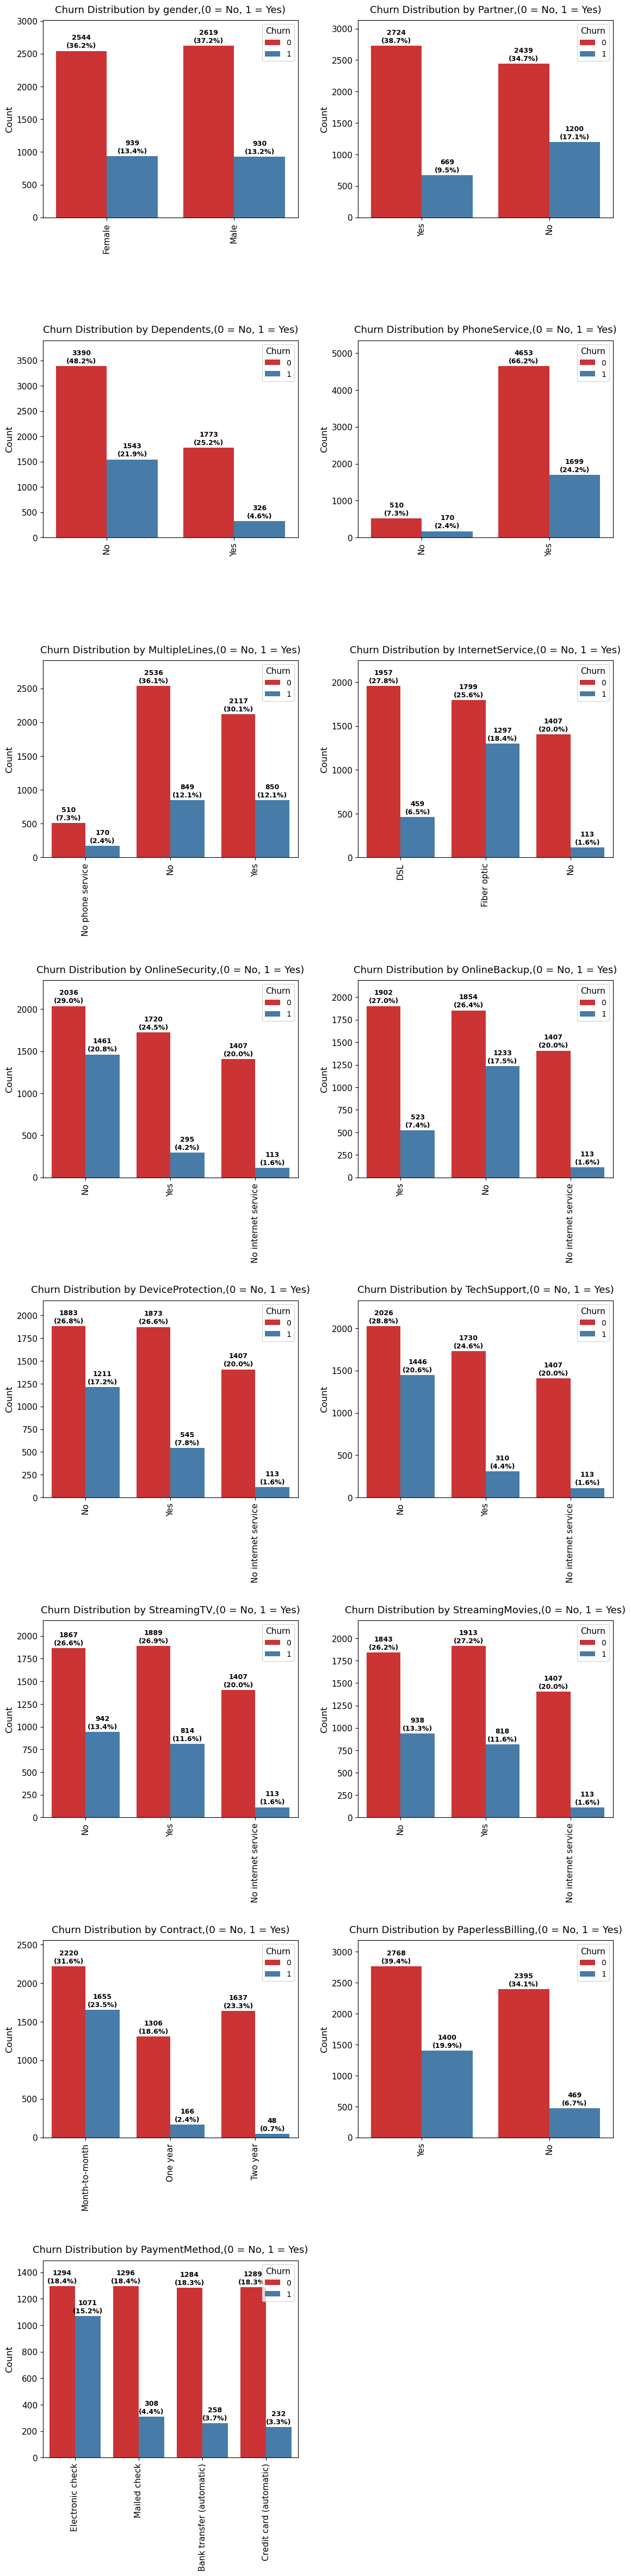

In [25]:
# Plot churn distribution for each categorical column
plt.figure(figsize=(12, 48))  

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(8, 2, i)
    ax = sns.countplot(x=col, hue='Churn', data=df, palette='Set1')

    # Titles and labels
    plt.title(f'Churn Distribution by {col},(0 = No, 1 = Yes)', fontsize=13, pad=10)
    plt.xlabel('')
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=90, fontsize=11)
    plt.yticks(fontsize=11)
    plt.legend(title='Churn', fontsize=10, title_fontsize=11, loc='upper right')

    # Add counts and percentages neatly
    total = len(df)
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f'{int(v)}\n({v/total*100:.1f}%)' for v in container.datavalues],
            label_type='edge',
            fontsize=9,
            fontweight='bold',
            padding=2,
            rotation=0,
            color='black'
        )

    # Make space for labels
    ax.margins(y=0.15)

plt.tight_layout(pad=3.0)
plt.show()


In [31]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

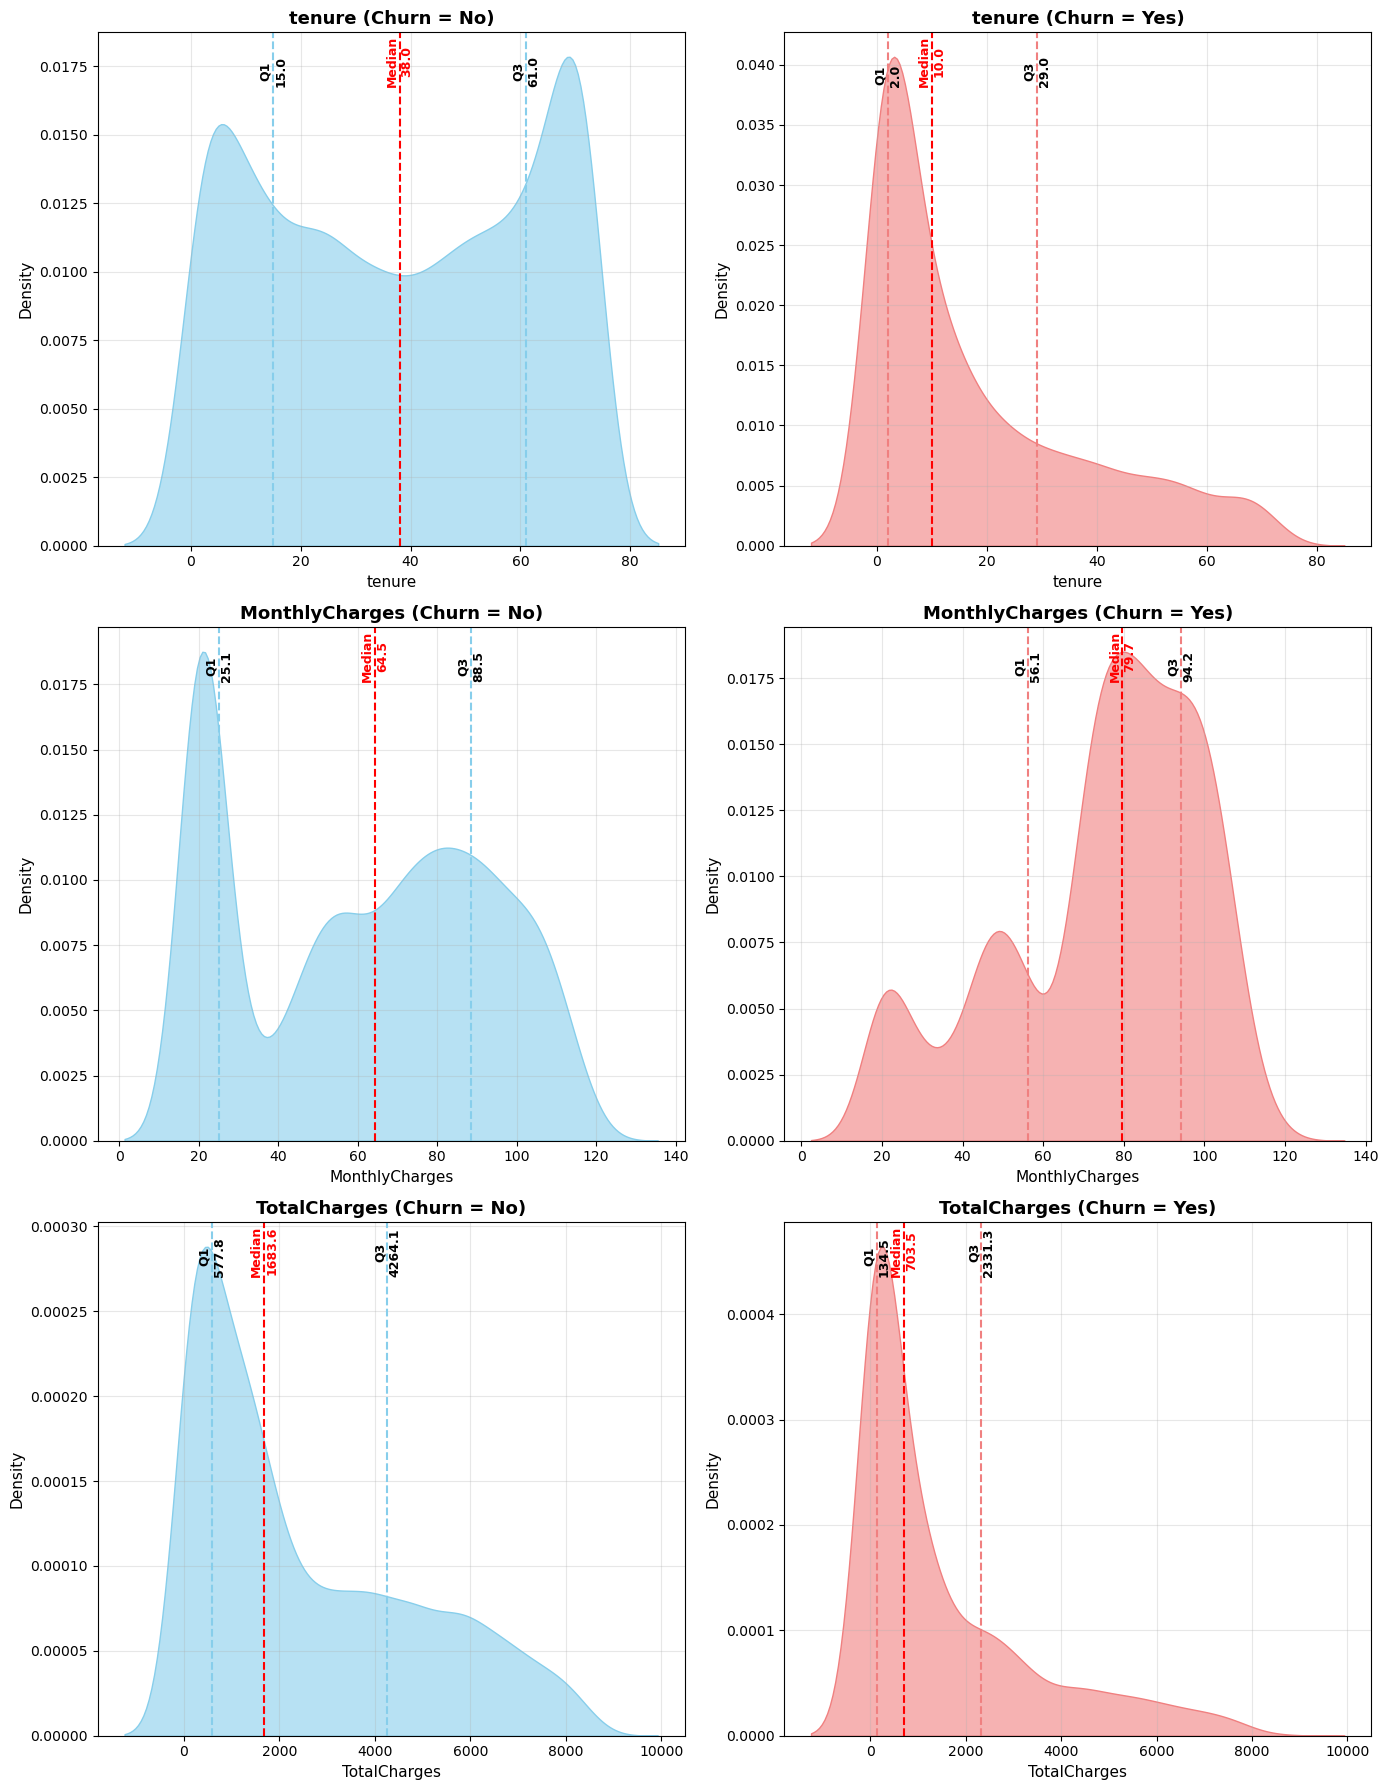

In [37]:
plt.figure(figsize=(14,18))

for i, col in enumerate(num_cols, 1):
    # --- Churn = No ---
    plt.subplot(len(num_cols), 2, 2*i - 1)
    subset_no = df[df['Churn'] == 0][col]
    
    sns.kdeplot(x=subset_no, fill=True, color='skyblue', alpha=0.6)
    
    # Quartiles for Churn = No
    q1, q2, q3 = subset_no.quantile([0.25, 0.5, 0.75])
    plt.axvline(q1, color='skyblue', linestyle='--', lw=1.5)
    plt.axvline(q2, color='red', linestyle='--', lw=1.5)
    plt.axvline(q3, color='skyblue', linestyle='--', lw=1.5)
    
    # Quartile labels
    y_max = plt.ylim()[1]
    plt.text(q1, y_max*0.9, f'Q1\n{q1:.1f}', color='black', fontsize=9, fontweight='bold', rotation=90, ha='center')
    plt.text(q2, y_max*0.9, f'Median\n{q2:.1f}', color='red', fontsize=9, fontweight='bold', rotation=90, ha='center')
    plt.text(q3, y_max*0.9, f'Q3\n{q3:.1f}', color='black', fontsize=9, fontweight='bold', rotation=90, ha='center')

    plt.title(f'{col} (Churn = No)', fontsize=13, fontweight='bold')
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Density', fontsize=11)
    plt.grid(alpha=0.3)

    # --- Churn = Yes ---
    plt.subplot(len(num_cols), 2, 2*i)
    subset_yes = df[df['Churn'] == 1][col]
    
    sns.kdeplot(x=subset_yes, fill=True, color='lightcoral', alpha=0.6)
    
    # Quartiles for Churn = Yes
    q1, q2, q3 = subset_yes.quantile([0.25, 0.5, 0.75])
    plt.axvline(q1, color='lightcoral', linestyle='--', lw=1.5)
    plt.axvline(q2, color='red', linestyle='--', lw=1.5)
    plt.axvline(q3, color='lightcoral', linestyle='--', lw=1.5)
    
    # Quartile labels
    y_max = plt.ylim()[1]
    plt.text(q1, y_max*0.9, f'Q1\n{q1:.1f}', color='black', fontsize=9, fontweight='bold', rotation=90, ha='center')
    plt.text(q2, y_max*0.9, f'Median\n{q2:.1f}', color='red', fontsize=9, fontweight='bold', rotation=90, ha='center')
    plt.text(q3, y_max*0.9, f'Q3\n{q3:.1f}', color='black', fontsize=9, fontweight='bold', rotation=90, ha='center')

    plt.title(f'{col} (Churn = Yes)', fontsize=13, fontweight='bold')
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Density', fontsize=11)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
quartile_summary = []

for col in num_cols:
    for churn_value in sorted(df['Churn'].unique()):
        subset = df[df['Churn'] == churn_value][col]
        q1, q2, q3 = subset.quantile([0.25, 0.5, 0.75])
        quartile_summary.append({
            'Feature': col,
            'Churn': churn_value,
            'Q1 (25%)': round(q1, 2),
            'Median (Q2)': round(q2, 2),
            'Q3 (75%)': round(q3, 2)
        })

# Convert to DataFrame
quartile_df = pd.DataFrame(quartile_summary)

# Display formatted table
print("Quartile Summary for Numerical Features by Churn")
display(quartile_df)

Quartile Summary for Numerical Features by Churn


,Feature,Churn,Q1 (25%),Median (Q2),Q3 (75%)
0,tenure,0,15.00,38.00,61.00
1,tenure,1,2.00,10.00,29.00
2,MonthlyCharges,0,25.10,64.45,88.47
3,MonthlyCharges,1,56.15,79.65,94.20
4,TotalCharges,0,577.83,1683.60,4264.12
5,TotalCharges,1,134.50,703.55,2331.30


                  tenure  MonthlyCharges  TotalCharges     Churn
tenure          1.000000        0.246862      0.825880 -0.354049
MonthlyCharges  0.246862        1.000000      0.651065  0.192858
TotalCharges    0.825880        0.651065      1.000000 -0.199484
Churn          -0.354049        0.192858     -0.199484  1.000000


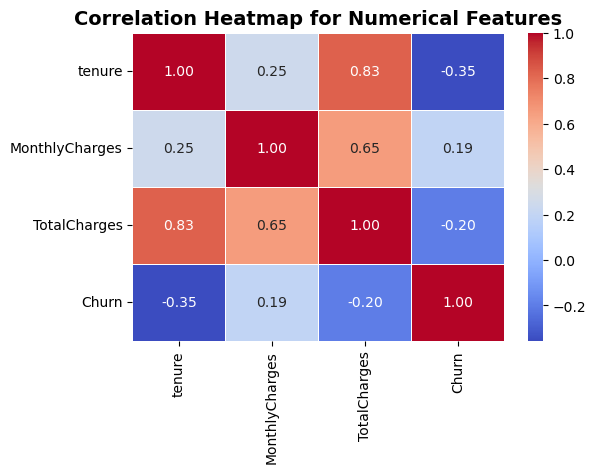

In [41]:
# Select numerical columns + Churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Display it neatly
print(corr_matrix)
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap for Numerical Features', fontsize=14, fontweight='bold')
plt.show()

# Feature Engineering (New Features + Interaction) and Encoding & Scaling

In [43]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges with median
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Average charges per month (avoid divide by zero)
df["AvgChargesPerMonth"] = df["TotalCharges"] / df["tenure"].replace(0, np.nan)
df["AvgChargesPerMonth"].fillna(df["AvgChargesPerMonth"].median(), inplace=True)

# Tenure group binning
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=["0-12", "13-24", "25-48", "49-60", "61-72"]
)

# Combine Contract and PaymentMethod
df["Contract_Payment"] = df["Contract"] + "_" + df["PaymentMethod"]

# Binary features
df["HighMonthlyCharges"] = (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int)
df["LongTenure"] = (df["tenure"] > 48).astype(int)
df["HighCharge_LongTenure"] = df["HighMonthlyCharges"] * df["LongTenure"]


# Identify categorical columns (exclude customerID)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != "customerID"]

# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Identify numerical columns (excluding target)
numerical_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != "Churn"]

# Standardize numeric features
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Encoded & scaled dataset shape:", df_encoded.shape)
display(df_encoded.head())

Encoded & scaled dataset shape: (7032, 48)


,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgChargesPerMonth,tenure_group,HighMonthlyCharges,LongTenure,...,Contract_Payment_Month-to-month_Electronic check,Contract_Payment_Month-to-month_Mailed check,Contract_Payment_One year_Bank transfer (automatic),Contract_Payment_One year_Credit card (automatic),Contract_Payment_One year_Electronic check,Contract_Payment_One year_Mailed check,Contract_Payment_Two year_Bank transfer (automatic),Contract_Payment_Two year_Credit card (automatic),Contract_Payment_Two year_Electronic check,Contract_Payment_Two year_Mailed check
0,7590-VHVEG,-0.440327,-1.280248,-1.161694,-0.994194,0,-1.157889,0-12,-0.999147,-0.683476,...,True,False,False,False,False,False,False,False,False,False
1,5575-GNVDE,-0.440327,0.064303,-0.260878,-0.173740,0,-0.305658,25-48,-0.999147,-0.683476,...,False,False,False,False,False,True,False,False,False,False
2,3668-QPYBK,-0.440327,-1.239504,-0.363923,-0.959649,1,-0.355305,0-12,-0.999147,-0.683476,...,False,True,False,False,False,False,False,False,False,False
3,7795-CFOCW,-0.440327,0.512486,-0.747850,-0.195248,0,-0.791614,25-48,-0.999147,-0.683476,...,False,False,True,False,False,False,False,False,False,False
4,9237-HQITU,-0.440327,-1.239504,0.196178,-0.940457,1,0.365282,0-12,1.000854,-0.683476,...,True,False,False,False,False,False,False,False,False,False


In [44]:
# Save to CSV
df_encoded.to_csv("processed_Telco-Customer-Churn_data.csv", index=False)
print("File saved as processed_Telco-Customer-Churn_data.csv")

File saved as processed_Telco-Customer-Churn_data.csv


# Feature Importance Baseline

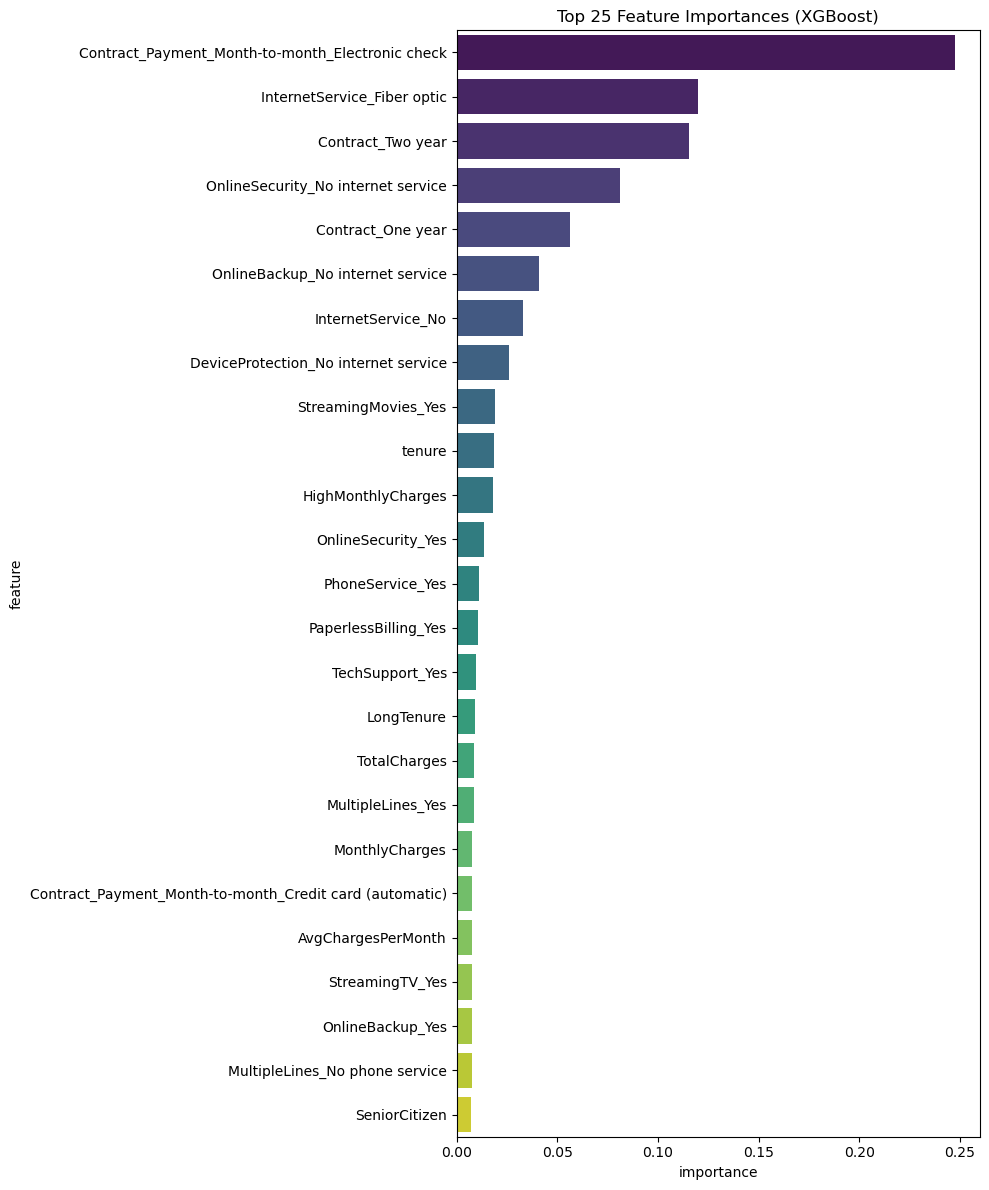

                                              feature  importance
35   Contract_Payment_Month-to-month_Electronic check    0.247620
14                        InternetService_Fiber optic    0.119923
29                                  Contract_Two year    0.115399
16                 OnlineSecurity_No internet service    0.081290
28                                  Contract_One year    0.056397
18                   OnlineBackup_No internet service    0.040968
15                                 InternetService_No    0.033122
20               DeviceProtection_No internet service    0.025926
27                                StreamingMovies_Yes    0.019342
1                                              tenure    0.018684
5                                  HighMonthlyCharges    0.018221
17                                 OnlineSecurity_Yes    0.013865
11                                   PhoneService_Yes    0.011116
30                               PaperlessBilling_Yes    0.010858
23        

In [22]:
# ------------------------------------------------
# 1. Load processed dataset
# ------------------------------------------------
df = pd.read_csv("processed_Telco-Customer-Churn_data.csv")

# ------------------------------------------------
# 2. Remove customerID (not useful)
# ------------------------------------------------
df = df.drop(columns=["customerID"])

# ------------------------------------------------
# 3. Convert boolean columns → int
# ------------------------------------------------
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

# ------------------------------------------------
# 4. Convert category → numeric codes
# ------------------------------------------------
cat_cols = df.select_dtypes(include=["category"]).columns
df[cat_cols] = df[cat_cols].apply(lambda col: col.cat.codes)

# ------------------------------------------------
# 5. Split X and y
# ------------------------------------------------
X = df.drop(columns=["Churn"])
y = df["Churn"]
X = X.select_dtypes(include=[np.number])

# ------------------------------------------------
# 6. XGBoost model
# ------------------------------------------------
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

# ------------------------------------------------
# 7. Feature importance + plot
# ------------------------------------------------
importances_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

top25 = importances_df.head(25)

plt.figure(figsize=(10, 12))
sns.barplot(data=top25, x="importance", y="feature", palette="viridis")
plt.title("Top 25 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

print(top25)

# ------------------------------------------------
# 8. Save reduced dataset (Top 25 + Churn)
# ------------------------------------------------
df_reduced = df[top25["feature"].tolist() + ["Churn"]]
df_reduced.to_csv("TelcoChurn_Top25_XGB.csv", index=False)

print("Saved: TelcoChurn_Top25_XGB.csv")
